In [1]:
import torch
import os
from pathlib import Path
import logging
import numpy as np
import time

# --- Add project root to sys.path ---
BASE_DIR = Path.cwd().parent.parent.parent
MODEL_PATH = BASE_DIR / "results" / "models"
DATA_DIR = BASE_DIR / "data" / "data_gnn"
ALL_DIR = DATA_DIR / "all"
RAW_DATA_DIR = BASE_DIR / "data" / "data_raw"
CACHE_DIR = BASE_DIR / "data" / "data_gnn"/ "cache"
# ------------------------------------

print(f"BASE_DIR: {BASE_DIR}")
print(f"MODEL_PATH: {MODEL_PATH}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"ALL_DIR: {ALL_DIR}")
print(f"RAW_DATA_DIR: {RAW_DATA_DIR}")

os.chdir(BASE_DIR)
from src.graph_modelling.models.spatialonlygnn import SpatialOnlyGCN
from src.graph_modelling.models.temporalonlygnn import SimpleChebGRU
from src.graph_modelling.datasets.no2_dataset import NO2DatasetLoader
from src.graph_modelling.training.train_utils import train_model_index, evaluate_index
from src.graph_modelling.visualization.visualization import (
    plot_training_history,
    plot_predictions,
    set_base_dir,
)
import inspect
import matplotlib.pyplot as plt
import seaborn as sns
import json

# A logger for this file
log = logging.getLogger(__name__)
log.setLevel(logging.INFO)

N_HOURS_IN = 72
N_HOURS_OUT = 24
N_HOURS_PRED = 24
OFFSET = 49

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


BASE_DIR: /home/nick/bachelor-project/third-copy
MODEL_PATH: /home/nick/bachelor-project/third-copy/results/models
DATA_DIR: /home/nick/bachelor-project/third-copy/data/data_gnn
ALL_DIR: /home/nick/bachelor-project/third-copy/data/data_gnn/all
RAW_DATA_DIR: /home/nick/bachelor-project/third-copy/data/data_raw
Using device: cuda


In [2]:
def plot_predictions_vs_ground_truth(predictions, targets, city_names=None, n_hours_in=72, n_hours_out=24,
                                    figsize=(14, 12), test_start_date="2021-12-09", 
                                    plot_start_date=None, plot_end_date=None, week=None):
    """
    Plot predictions versus ground truth for a specific date range, separating by city.
    
    Parameters:
    -----------
    predictions : list or np.ndarray
        Predictions array, if 2D should be [time, city]
    targets : list or np.ndarray
        Ground truth array, if 2D should be [time, city]
    city_names : list
        Names of the cities
    n_hours_in : int
        Number of hours used as input
    n_hours_out : int
        Number of hours predicted
    figsize : tuple
        Figure size (width, height)
    test_start_date : str
        Start date of the test set in YYYY-MM-DD format
    plot_start_date : str
        Start date to plot in YYYY-MM-DD format (e.g., "2021-12-20")
    plot_end_date : str
        End date to plot in YYYY-MM-DD format (e.g., "2021-12-27")
    week : int
        Week number to plot if plot_start_date/plot_end_date are not provided
    """
    import datetime
    import matplotlib.dates as mdates
    
    # Convert to numpy arrays
    preds = np.array(predictions)
    truth = np.array(targets)
    
    # Check if predictions/targets are 2D (multiple cities)
    is_multi_city = len(preds.shape) > 1 and preds.shape[1] > 1
    num_cities = preds.shape[1] if is_multi_city else 1
    
    # Use default city names if none provided
    if city_names is None:
        city_names = [f"City {i+1}" for i in range(num_cities)]
    
    # Create a time array for the entire dataset
    test_start = datetime.datetime.strptime(test_start_date, "%Y-%m-%d")
    total_hours = len(preds) if len(preds.shape) == 1 else preds.shape[0]
    all_dates = [test_start + datetime.timedelta(hours=int(h)) for h in range(total_hours)]
    
    # Determine the plotting range
    if plot_start_date and plot_end_date:
        start_date = datetime.datetime.strptime(plot_start_date, "%Y-%m-%d")
        end_date = datetime.datetime.strptime(plot_end_date, "%Y-%m-%d")
        
        # Find the indices that correspond to the date range
        start_idx = None
        end_idx = None
        
        for i, date in enumerate(all_dates):
            if start_idx is None and date >= start_date:
                start_idx = i
            if end_idx is None and date >= end_date:
                end_idx = i
                break
        
        # Handle case where end_date is beyond data range
        if end_idx is None:
            end_idx = total_hours
            
        # Handle case where start_date is beyond data range
        if start_idx is None:
            start_idx = 0
    else:
        # Default to week-based selection if dates aren't provided
        if week is None:
            week = 1  # Default to first week
            
        hours_per_week = 7 * 24
        start_idx = (week - 1) * hours_per_week
        end_idx = min(start_idx + hours_per_week, total_hours)
    
    # Extract the dates for our plotting range
    dates = all_dates[start_idx:end_idx]
    
    # Create the plot with subplots for each city
    fig, axes = plt.subplots(num_cities, 1, figsize=figsize, sharex=True)
    
    # Make axes iterable even if there's only one city
    if num_cities == 1:
        axes = [axes]
    
    for i in range(num_cities):
        ax = axes[i]
        
        # Extract the data for this city and the specified date range
        if is_multi_city:
            range_preds = preds[start_idx:end_idx, i]
            range_truth = truth[start_idx:end_idx, i]
        else:
            range_preds = preds[start_idx:end_idx]
            range_truth = truth[start_idx:end_idx]
        
        # Plot ground truth
        ax.plot(dates, range_truth, 'black', label='Ground Truth', linewidth=2)
        
        # Plot predictions
        ax.plot(dates, range_preds, 'red', label='Predictions', linewidth=2)
        
        # Set y-axis ticks (3-4 ticks)
        y_min, y_max = ax.get_ylim()
        ax.yaxis.set_major_locator(plt.MaxNLocator(4))  # Limit to 4 ticks
        
        # Add city name to the subplot title (without metrics)
        ax.set_title(f'{city_names[i]}', fontsize=14)
        
        # Add grid
        ax.grid(True, alpha=0.3)
        
        # Only add legend to the first subplot to save space
        if i == 0:
            ax.legend(fontsize=12)
    
    # Format the x-axis (only apply to the shared x-axis)
    ax = axes[-1]  # Get the last axis which has the visible x-axis ticks
    
    # Set daily ticks
    day_dates = []
    current_date = dates[0].replace(hour=0, minute=0, second=0, microsecond=0)
    last_date = dates[-1]
    
    while current_date <= last_date:
        day_dates.append(current_date)
        current_date += datetime.timedelta(days=1)
    
    ax.set_xticks(day_dates)
    
    # Only show the first and last date labels
    date_labels = ['' for _ in day_dates]
    date_labels[0] = day_dates[0].strftime('%b %d')
    date_labels[-1] = day_dates[-1].strftime('%b %d')
    ax.set_xticklabels(date_labels)
    
    # Add grid lines for days
    ax.grid(True, which='major', axis='x', alpha=0.3)
    
    
    # Add y-axis label on the far left (outside the plots)
    fig.text(0.02, 0.5, 'NO2 Concentration', va='center', rotation='vertical', fontsize=14)

    # Increase y-axis label fontsize
    for ax in axes:
        ax.yaxis.label.set_size(40)
    
    # Adjust the plot title
    date_range_str = f'{dates[0].strftime("%b %d, %Y")} to {dates[-1].strftime("%b %d, %Y")}'
    fig.suptitle(f'Predictions vs Ground Truth ({date_range_str})', fontsize=16)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, hspace=0.3, left=0.07)  # Increase left margin for y-axis label
    
    # Rotate x-axis tick labels for better readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    return fig

# GNN

## Spatial Inference


### Plot

In [3]:
# Plot inference of spatial model based on json
with open("results/gnn_results/SpatialOnlyGCN_all_vars_inference_results.json") as f:
    spatial_data = json.load(f)
spatial_data

{'model_name': 'SpatialOnlyGCN_all_vars',
 'city_data': {'Amsterdam': {'predictions': [21.4134521484375,
    18.575437545776367,
    18.28845977783203,
    17.945871353149414,
    21.176977157592773,
    19.910058975219727,
    25.742961883544922,
    29.028833389282227,
    25.430583953857422,
    29.02625274658203,
    23.613685607910156,
    22.775976181030273,
    23.868803024291992,
    25.227754592895508,
    26.915424346923828,
    24.344188690185547,
    25.9776611328125,
    24.959171295166016,
    21.004863739013672,
    17.543243408203125,
    16.363210678100586,
    16.25624656677246,
    13.677696228027344,
    11.179815292358398,
    15.250741004943848,
    15.644871711730957,
    12.914761543273926,
    15.03412914276123,
    16.633281707763672,
    17.362651824951172,
    16.696210861206055,
    22.651527404785156,
    16.46651840209961,
    18.362932205200195,
    17.6213321685791,
    14.972085952758789,
    17.97775650024414,
    17.55039405822754,
    17.64645576477

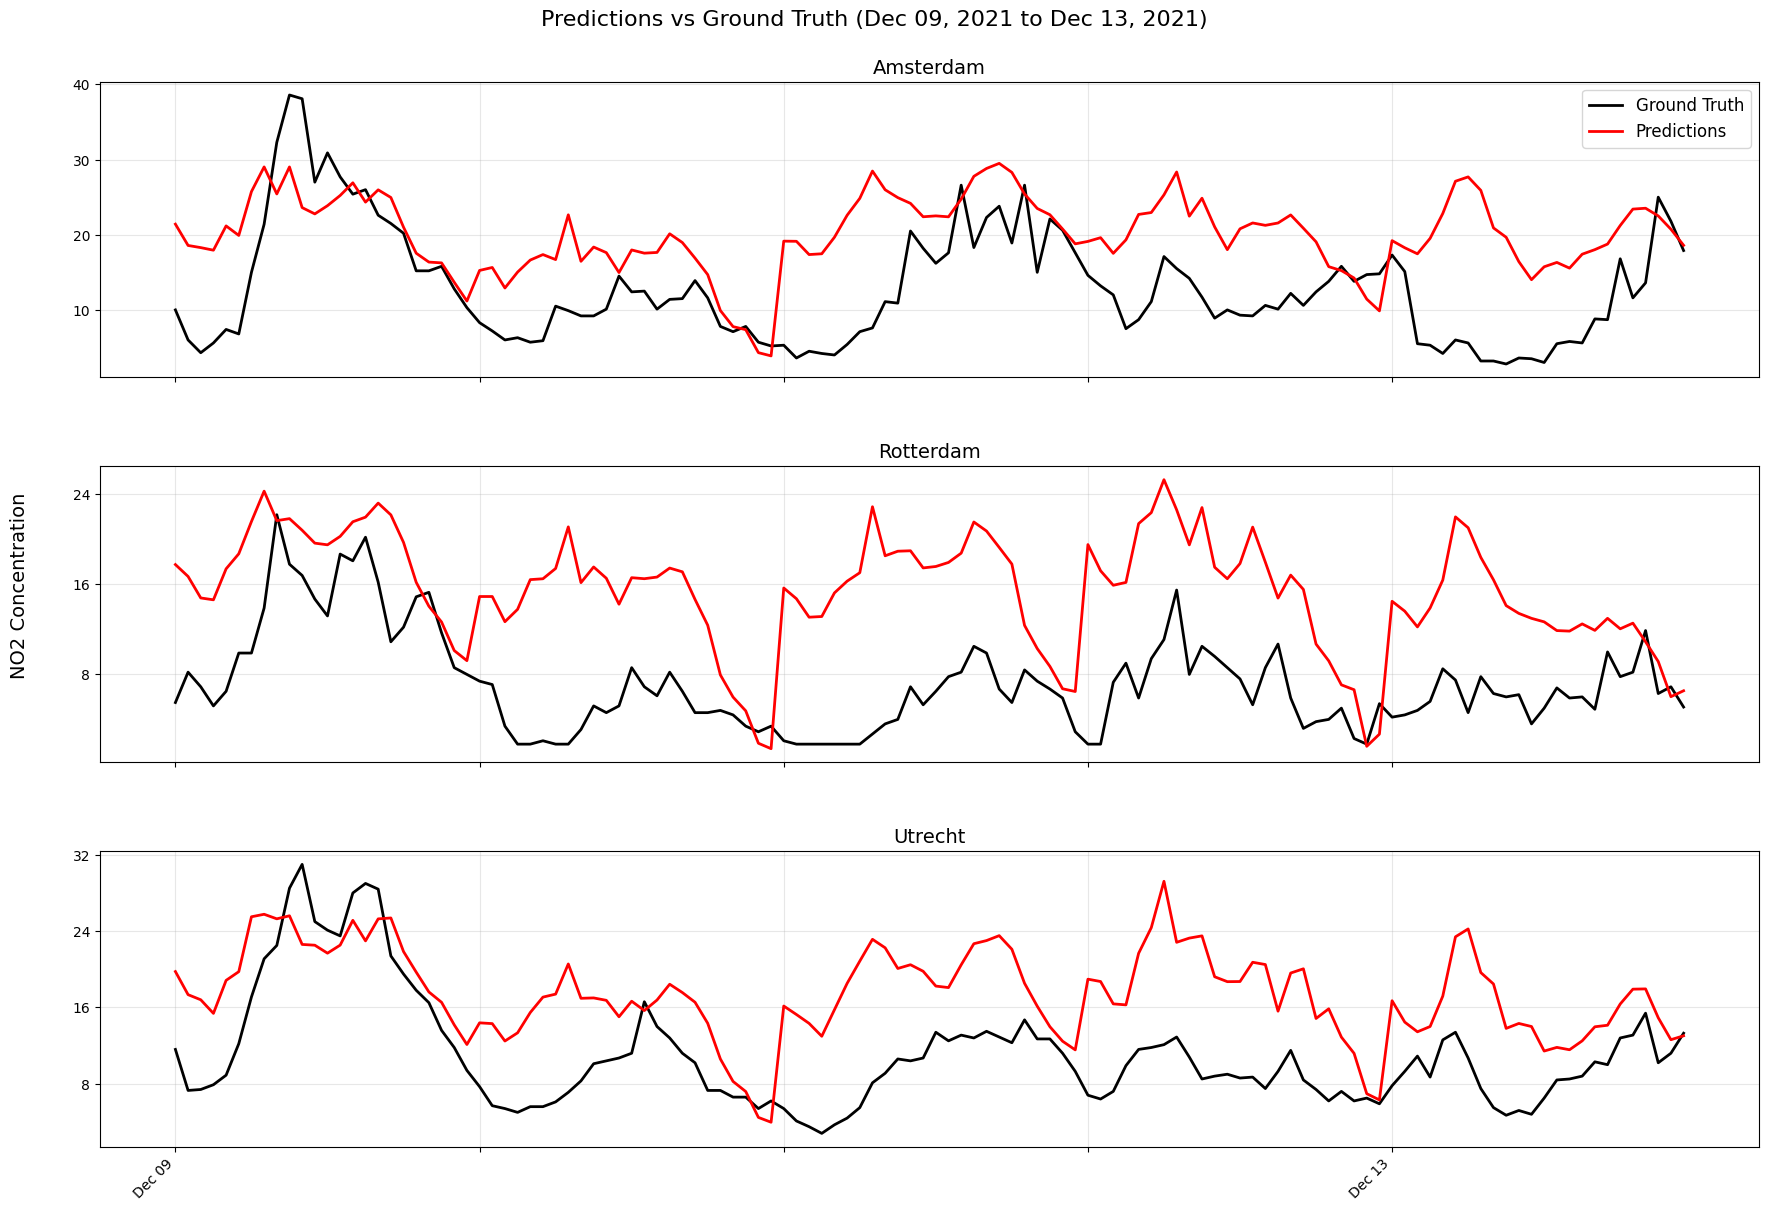

In [4]:
# Load data with the new structure
with open("results/gnn_results/SpatialOnlyGCN_all_vars_inference_results.json") as f:
    spatial_data = json.load(f)

# Extract city names
city_names = spatial_data["city_names"]

# Prepare arrays for plotting
predictions = []
targets = []

# Extract city-specific data
for city in city_names:
    city_pred = spatial_data["city_data"][city]["predictions"]
    city_tgt = spatial_data["city_data"][city]["targets"]
    predictions.append(city_pred)
    targets.append(city_tgt)
    
# Convert to proper shape for plotting [time, city]
predictions = np.array(predictions).T  # Transpose to get [time, city]
targets = np.array(targets).T

# Now plot with the properly structured data
fig = plot_predictions_vs_ground_truth(
    predictions, 
    targets, 
    city_names=city_names, 
    plot_start_date="2021-12-05",
    plot_end_date="2021-12-14",
    n_hours_in=N_HOURS_IN, 
    n_hours_out=N_HOURS_OUT, 
    figsize=(18, 12),
    test_start_date="2021-12-09"
)

## ASTGCN Inference

### Plot

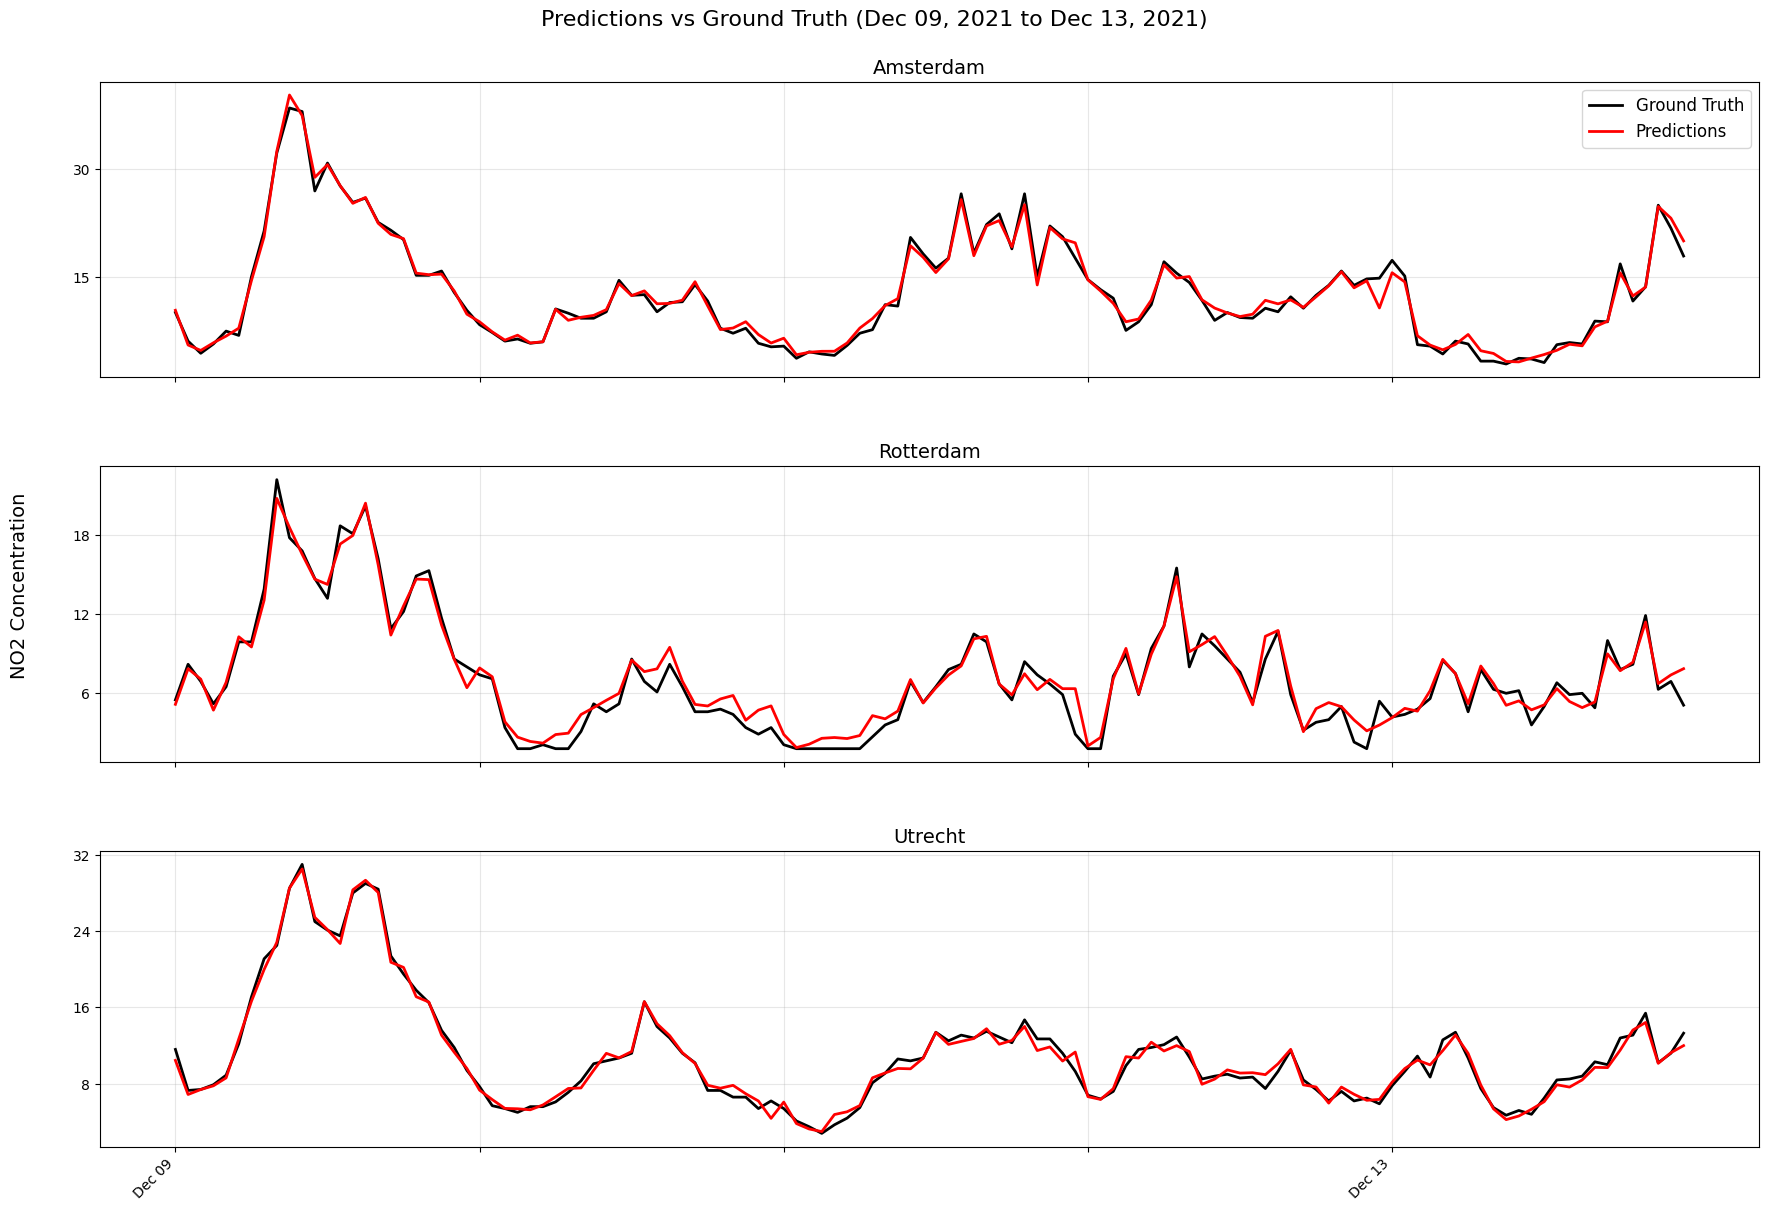

In [5]:
# Load data with the new structure
with open("results/gnn_results/ASTGCN_all_vars_inference_results.json") as f:
    astgcn_data = json.load(f)

# Extract city names
city_names = astgcn_data["city_names"]

# Prepare arrays for plotting
predictions = []
targets = []

# Extract city-specific data
for city in city_names:
    city_pred = astgcn_data["city_data"][city]["predictions"]
    city_tgt = astgcn_data["city_data"][city]["targets"]
    predictions.append(city_pred)
    targets.append(city_tgt)
    
# Convert to proper shape for plotting [time, city]
predictions = np.array(predictions).T  # Transpose to get [time, city]
targets = np.array(targets).T

# Now plot with the properly structured data
fig = plot_predictions_vs_ground_truth(
    predictions, 
    targets, 
    city_names=city_names, 
    plot_start_date="2021-12-05",
    plot_end_date="2021-12-14",
    n_hours_in=N_HOURS_IN, 
    n_hours_out=N_HOURS_OUT, 
    figsize=(18, 12),
    test_start_date="2021-12-09"
)

## ChebGru Inference

### Plot

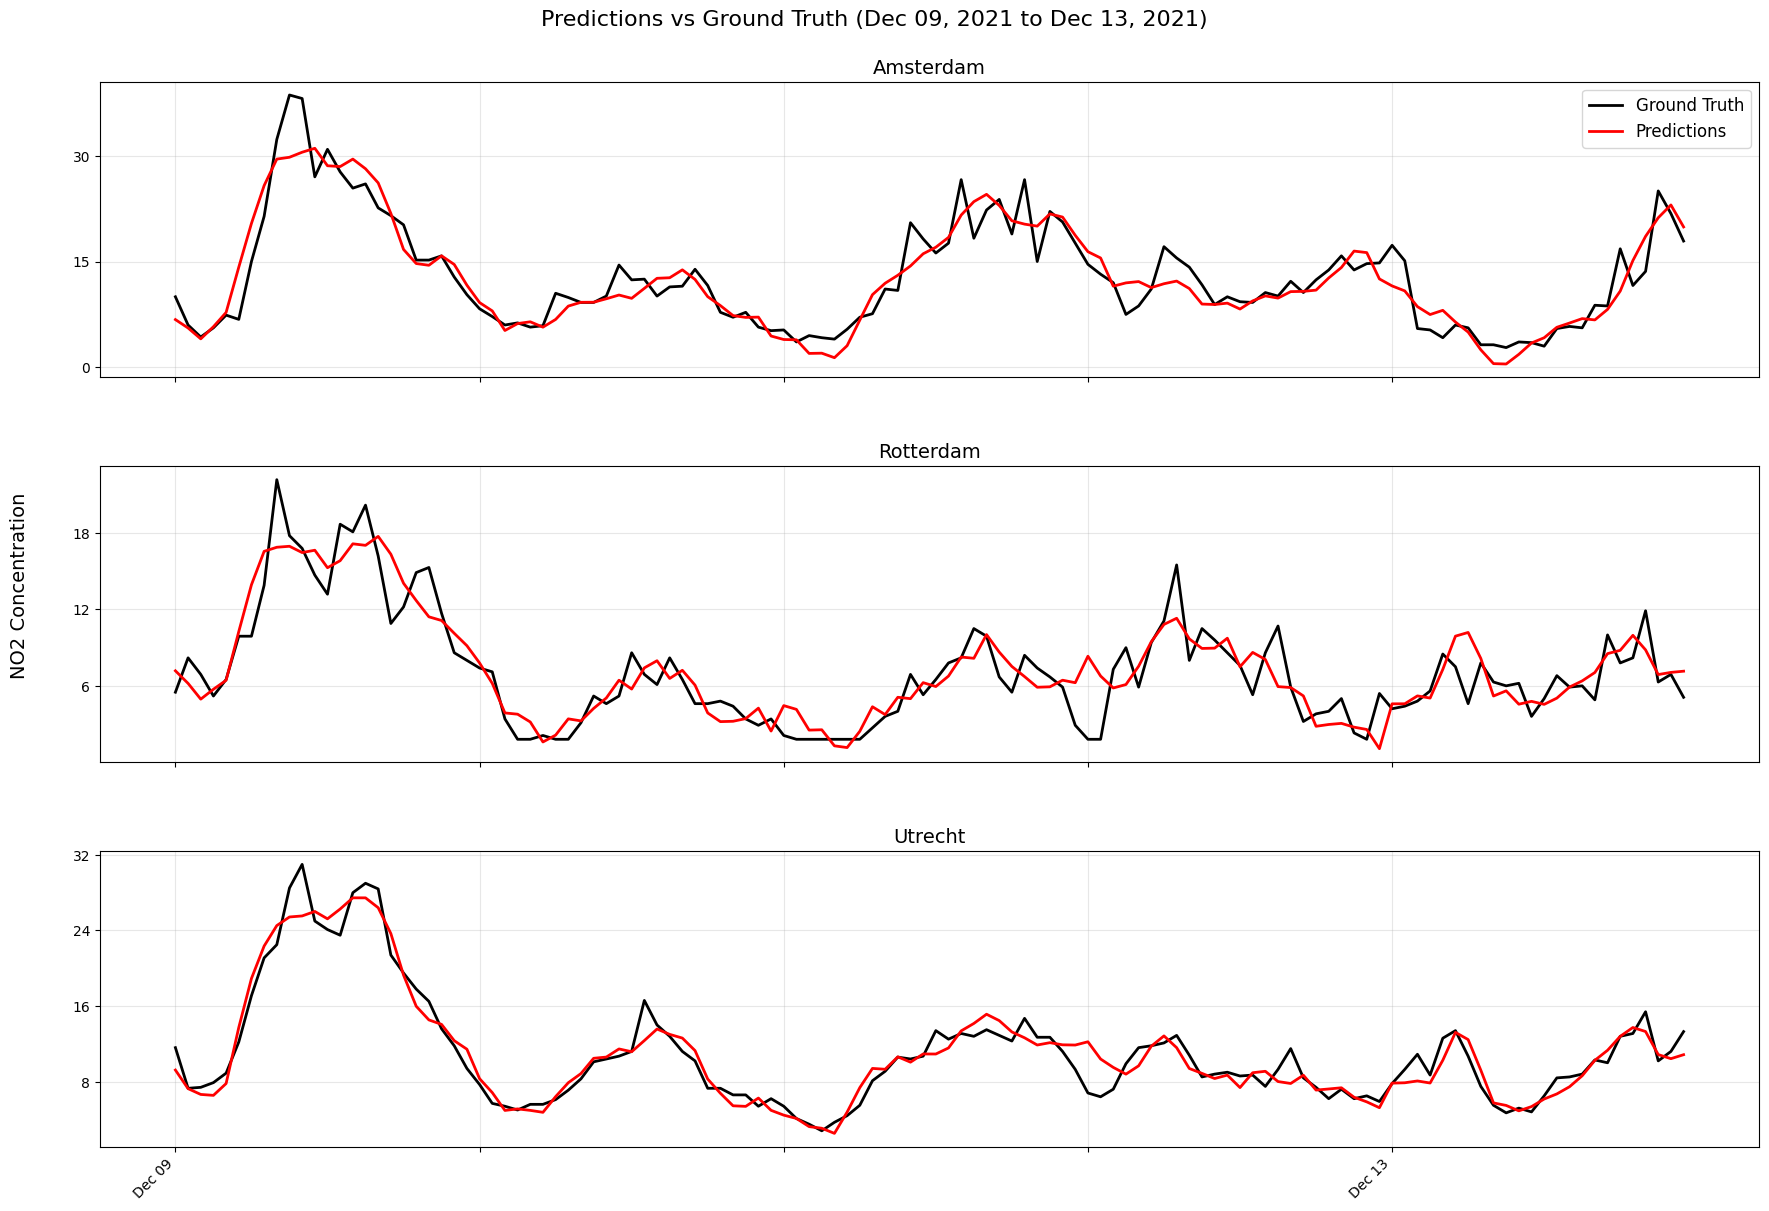

In [6]:
# Load data with the new structure
with open("results/gnn_results/SimpleChebGRU_all_vars_inference_results.json") as f:
    chebgru_data = json.load(f)

# Extract city names
city_names = chebgru_data["city_names"]

# Prepare arrays for plotting
predictions = []
targets = []

# Extract city-specific data
for city in city_names:
    city_pred = chebgru_data["city_data"][city]["predictions"]
    city_tgt = chebgru_data["city_data"][city]["targets"]
    predictions.append(city_pred)
    targets.append(city_tgt)
    
# Convert to proper shape for plotting [time, city]
predictions = np.array(predictions).T  # Transpose to get [time, city]
targets = np.array(targets).T

# Now plot with the properly structured data
fig = plot_predictions_vs_ground_truth(
    predictions, 
    targets, 
    city_names=city_names, 
    plot_start_date="2021-12-05",
    plot_end_date="2021-12-14",
    n_hours_in=N_HOURS_IN, 
    n_hours_out=N_HOURS_OUT, 
    figsize=(18, 12),
    test_start_date="2021-12-09"
)

## All comparison

In [7]:
def plot_model_comparison(model_data_dict, city_names, n_hours_in=72, n_hours_out=24,
                         figsize=(14, 12), test_start_date="2021-12-09", 
                         plot_start_date=None, plot_end_date=None, week=None,
                         model_colors=None):
    """
    Plot predictions from multiple models versus ground truth for comparison.
    
    Parameters:
    -----------
    model_data_dict : dict
        Dictionary where keys are model names and values are dictionaries with
        'predictions' and 'targets' data for each model
    city_names : list
        Names of the cities
    n_hours_in : int
        Number of hours used as input
    n_hours_out : int
        Number of hours predicted
    figsize : tuple
        Figure size (width, height)
    test_start_date : str
        Start date of the test set in YYYY-MM-DD format
    plot_start_date : str
        Start date to plot in YYYY-MM-DD format (e.g., "2021-12-20")
    plot_end_date : str
        End date to plot in YYYY-MM-DD format (e.g., "2021-12-27")
    week : int
        Week number to plot if plot_start_date/plot_end_date are not provided
    model_colors : dict
        Dictionary mapping model names to colors
    """
    import datetime
    import matplotlib.dates as mdates
    
    # Default colors if none provided
    if model_colors is None:
        model_colors = {
            'SpatialOnlyGCN': 'blue',
            'ASTGCN': 'red',
            'SimpleChebGRU': 'green',
            'Ground Truth': 'black'
        }
    
    # Determine the number of cities from the first model
    first_model = list(model_data_dict.keys())[0]
    num_cities = len(city_names)
    
    # Create a time array for the entire dataset using the first model's data
    test_start = datetime.datetime.strptime(test_start_date, "%Y-%m-%d")
    
    # Use the shape from the first model to determine total hours
    preds = model_data_dict[first_model]['predictions']
    total_hours = preds.shape[0]
    all_dates = [test_start + datetime.timedelta(hours=int(h)) for h in range(total_hours)]
    
    # Determine the plotting range
    if plot_start_date and plot_end_date:
        start_date = datetime.datetime.strptime(plot_start_date, "%Y-%m-%d")
        end_date = datetime.datetime.strptime(plot_end_date, "%Y-%m-%d")
        
        # Find the indices that correspond to the date range
        start_idx = None
        end_idx = None
        
        for i, date in enumerate(all_dates):
            if start_idx is None and date >= start_date:
                start_idx = i
            if end_idx is None and date >= end_date:
                end_idx = i
                break
        
        # Handle case where end_date is beyond data range
        if end_idx is None:
            end_idx = total_hours
            
        # Handle case where start_date is beyond data range
        if start_idx is None:
            start_idx = 0
    else:
        # Default to week-based selection if dates aren't provided
        if week is None:
            week = 1  # Default to first week
            
        hours_per_week = 7 * 24
        start_idx = (week - 1) * hours_per_week
        end_idx = min(start_idx + hours_per_week, total_hours)
    
    # Extract the dates for our plotting range
    dates = all_dates[start_idx:end_idx]
    
    # Create the plot with subplots for each city
    fig, axes = plt.subplots(num_cities, 1, figsize=figsize, sharex=True)
    
    # Make axes iterable even if there's only one city
    if num_cities == 1:
        axes = [axes]
    
    # Plot for each city
    for i in range(num_cities):
        ax = axes[i]
        
        # First plot ground truth (same for all models)
        # Use the ground truth from the first model
        ground_truth = model_data_dict[first_model]['targets'][start_idx:end_idx, i]
        ax.plot(dates, ground_truth, color=model_colors.get('Ground Truth', 'black'), 
                label='Ground Truth', linewidth=2)
        
        # Plot predictions for each model
        for model_name, model_data in model_data_dict.items():
            model_preds = model_data['predictions'][start_idx:end_idx, i]
            ax.plot(dates, model_preds, color=model_colors.get(model_name, 'gray'),
                    label=f'{model_name}', linewidth=2, linestyle='--')
        
        # Set y-axis ticks (3-4 ticks)
        ax.yaxis.set_major_locator(plt.MaxNLocator(4))
        
        # Add city name to the subplot title
        ax.set_title(f'{city_names[i]}', fontsize=14)
        
        # Add grid
        ax.grid(True, alpha=0.3)
        
        # Only add legend to the first subplot to save space
        if i == 0:
            ax.legend(fontsize=12)
    
    # Format the x-axis (only apply to the shared x-axis)
    ax = axes[-1]  # Get the last axis which has the visible x-axis ticks
    
    # Set daily ticks
    day_dates = []
    current_date = dates[0].replace(hour=0, minute=0, second=0, microsecond=0)
    last_date = dates[-1]
    
    while current_date <= last_date:
        day_dates.append(current_date)
        current_date += datetime.timedelta(days=1)
    
    ax.set_xticks(day_dates)
    
    # Only show the first and last date labels
    date_labels = ['' for _ in day_dates]
    date_labels[0] = day_dates[0].strftime('%b %d')
    date_labels[-1] = day_dates[-1].strftime('%b %d')
    ax.set_xticklabels(date_labels)
    
    # Add grid lines for days
    ax.grid(True, which='major', axis='x', alpha=0.3)
    
    # Add y-axis label on the far left (outside the plots)
    fig.text(0.02, 0.5, 'NO2 Concentration', va='center', rotation='vertical', fontsize=14)
    
    # Adjust the plot title
    date_range_str = f'{dates[0].strftime("%b %d, %Y")} to {dates[-1].strftime("%b %d, %Y")}'
    fig.suptitle(f'Model Comparison ({date_range_str})', fontsize=16)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, hspace=0.3, left=0.07)  # Increase left margin for y-axis label
    
    # Rotate x-axis tick labels for better readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    return fig

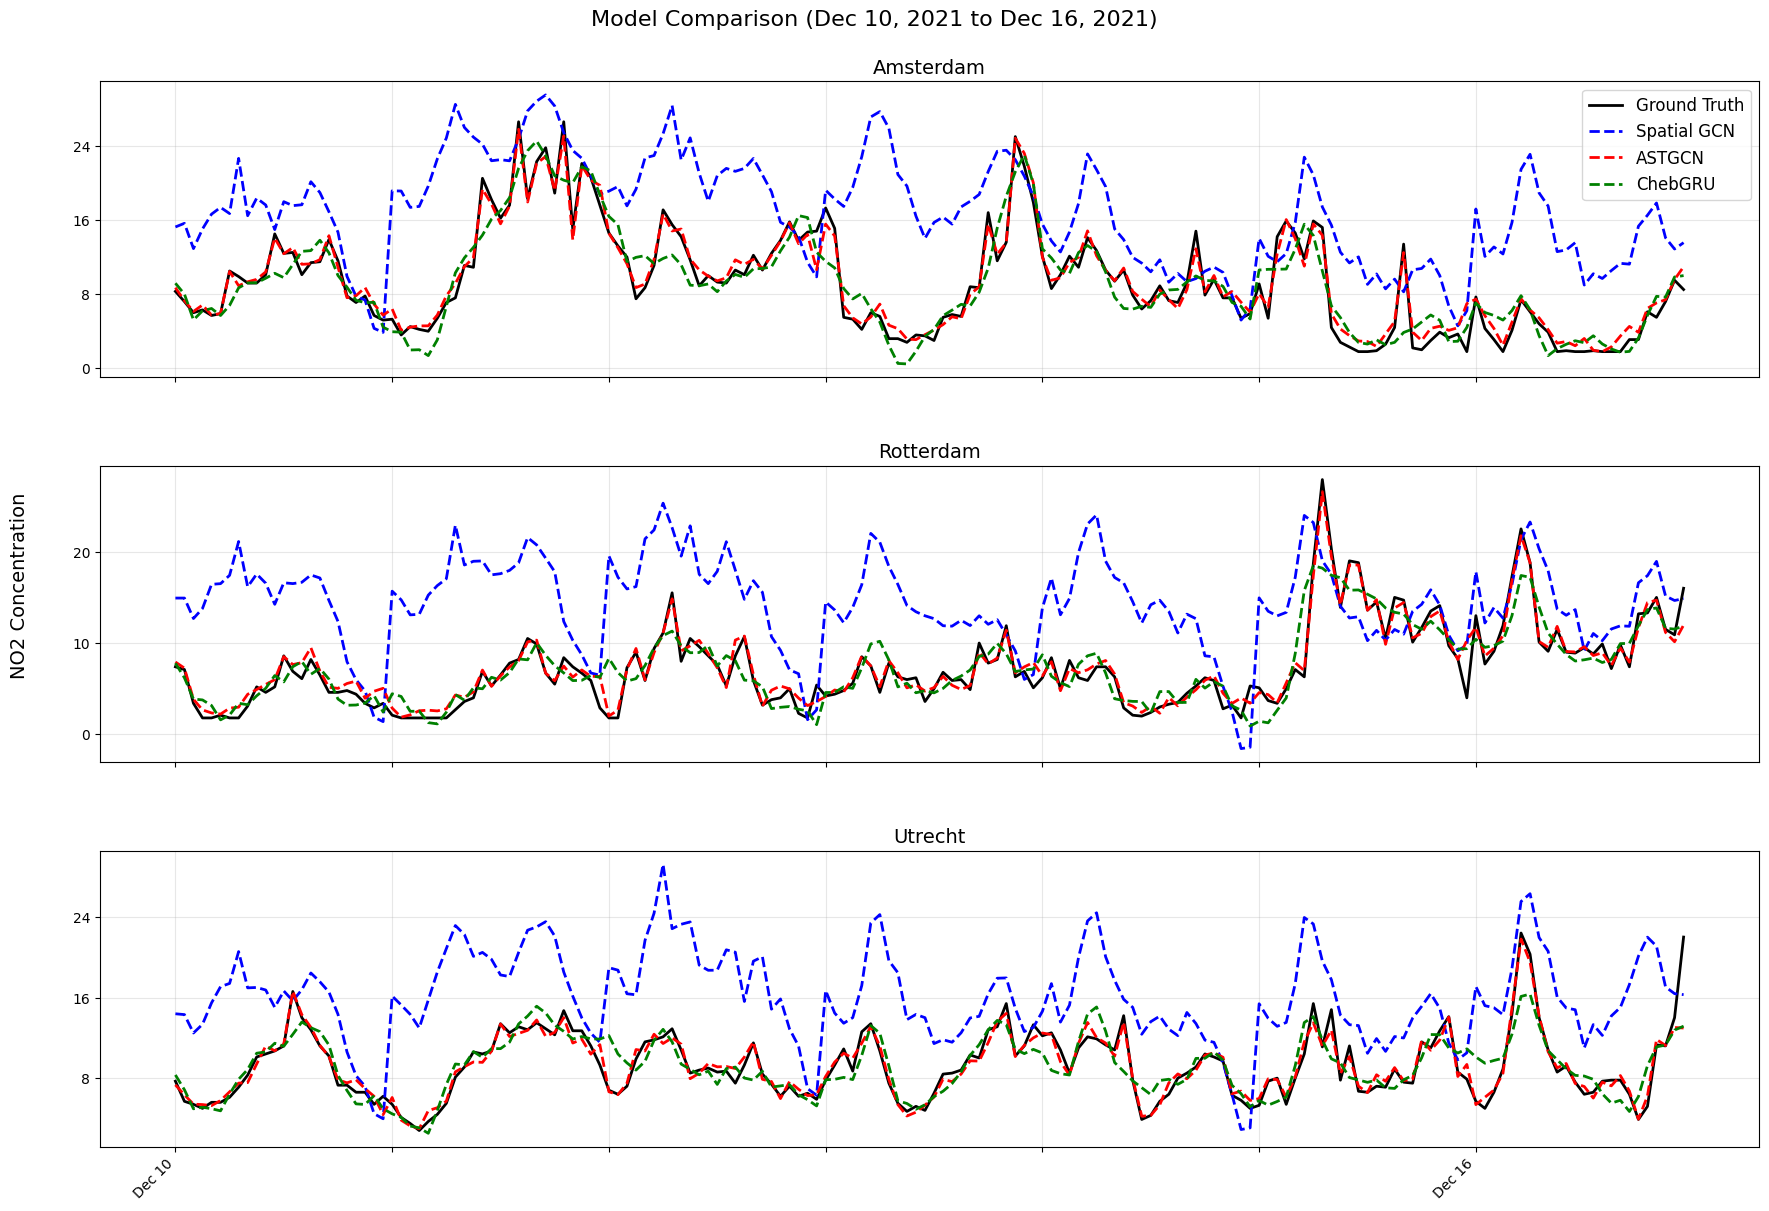

In [8]:
# Load data for each model
with open("results/gnn_results/SpatialOnlyGCN_all_vars_inference_results.json") as f:
    spatial_data = json.load(f)
    
with open("results/gnn_results/ASTGCN_all_vars_inference_results.json") as f:
    astgcn_data = json.load(f)
    
with open("results/gnn_results/SimpleChebGRU_all_vars_inference_results.json") as f:
    chebgru_data = json.load(f)

# Extract city names (should be the same for all models)
city_names = spatial_data["city_names"]

# Prepare arrays for each model
model_predictions = {}

# Function to process model data
def process_model_data(model_data):
    preds = []
    targets = []
    for city in city_names:
        city_pred = model_data["city_data"][city]["predictions"]
        city_tgt = model_data["city_data"][city]["targets"]
        preds.append(city_pred)
        targets.append(city_tgt)
    # Convert to shape [time, city]
    return {
        "predictions": np.array(preds).T,
        "targets": np.array(targets).T
    }

# Process each model's data
spatial_processed = process_model_data(spatial_data)
astgcn_processed = process_model_data(astgcn_data)
chebgru_processed = process_model_data(chebgru_data)

# Create a dictionary with all models
model_data_dict = {
    "Spatial GCN": spatial_processed,
    "ASTGCN": astgcn_processed,
    "ChebGRU": chebgru_processed
}

# Define colors for each model
model_colors = {
    "Spatial GCN": "blue",
    "ASTGCN": "red",
    "ChebGRU": "green",
    "Ground Truth": "black"
}

# Create comparison plot
fig = plot_model_comparison(
    model_data_dict,
    city_names,
    plot_start_date="2021-12-10",
    plot_end_date="2021-12-17",
    n_hours_in=N_HOURS_IN,
    n_hours_out=N_HOURS_OUT,
    figsize=(18, 12),
    test_start_date="2021-12-09",
    model_colors=model_colors
)

# Save the figure if needed
# fig.savefig('model_comparison.png', dpi=300, bbox_inches='tight')

# GRU

In [14]:
def process_gru_amsterdam_data(json_path, city_name="Amsterdam"):
    """
    Process GRU Amsterdam data from JSON to extract NO2 predictions and targets
    
    Parameters:
    -----------
    json_path : str
        Path to the GRU inference results JSON file
    city_name : str
        Name of the city (default: "Amsterdam")
        
    Returns:
    --------
    dict
        Dictionary with processed predictions and targets arrays
    """
    import json
    import numpy as np
    
    # Load the GRU data
    with open(json_path) as f:
        gru_data = json.load(f)
    
    # Extract predictions - getting the second value (NO2) from each prediction
    predictions = []
    for pred_batch in gru_data["predictions"]:
        if pred_batch and len(pred_batch) > 0:
            # Check if there's at least one prediction value with contents
            if pred_batch[0] and len(pred_batch[0]) > 0:
                # Extract NO2 value (index 1 or second element)
                if len(pred_batch[0]) > 1:
                    predictions.append(pred_batch[0][1])  # NO2 is the second value
    
    # Extract targets - getting the second value (NO2) from each target
    targets = []
    for target_batch in gru_data["targets"]:
        if target_batch and len(target_batch) > 0:
            # Check if there's at least one target value with contents
            if target_batch[0] and len(target_batch[0]) > 0:
                # Extract NO2 value (index 1 or second element)
                if len(target_batch[0]) > 1:
                    targets.append(target_batch[0][1])  # NO2 is the second value
    
    # Convert to numpy arrays
    predictions = np.array(predictions)
    targets = np.array(targets)
    
    # Reshape to match the expected format [time, city]
    predictions = predictions.reshape(-1, 1)
    targets = targets.reshape(-1, 1)
    
    return {
        "predictions": predictions,
        "targets": targets,
        "city_names": [city_name]
    }

## Amsterdam

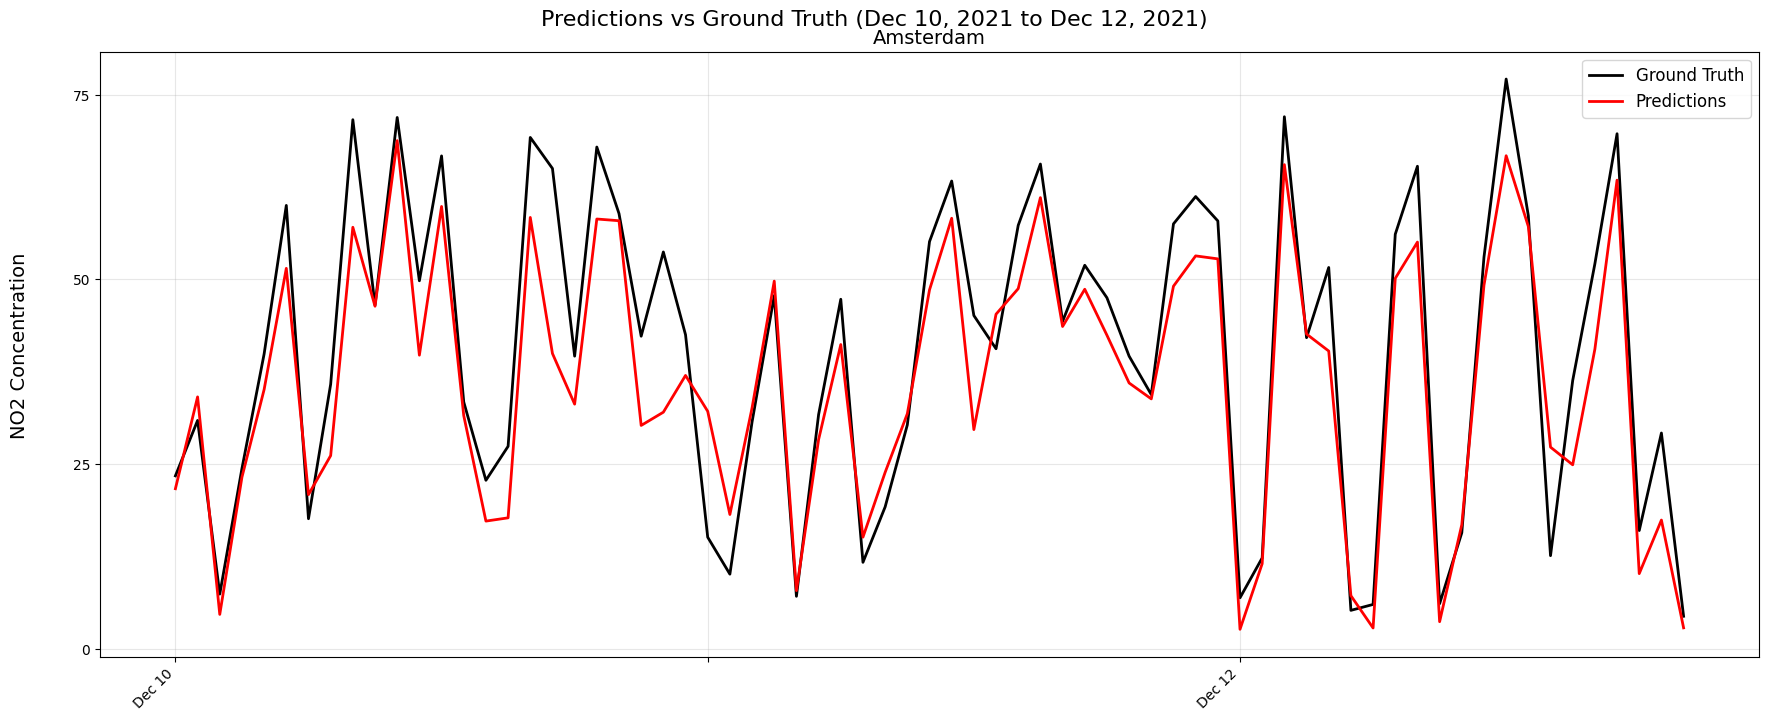

In [ ]:
# Process GRU data specifically for NO2
gru_no2_data = process_gru_amsterdam_data("results/gnn_results/GRU_Amsterdam_inference_results_per_eval.json")

# Plot GRU NO2 predictions vs targets
fig = plot_predictions_vs_ground_truth(
    gru_no2_data["predictions"],
    gru_no2_data["targets"],
    city_names=gru_no2_data["city_names"],
    plot_start_date="2021-12-10",
    plot_end_date="2021-12-17",
    n_hours_in=N_HOURS_IN,
    n_hours_out=N_HOURS_OUT,
    figsize=(18, 7),
    test_start_date="2021-12-09"
    
)



## Rotterdam


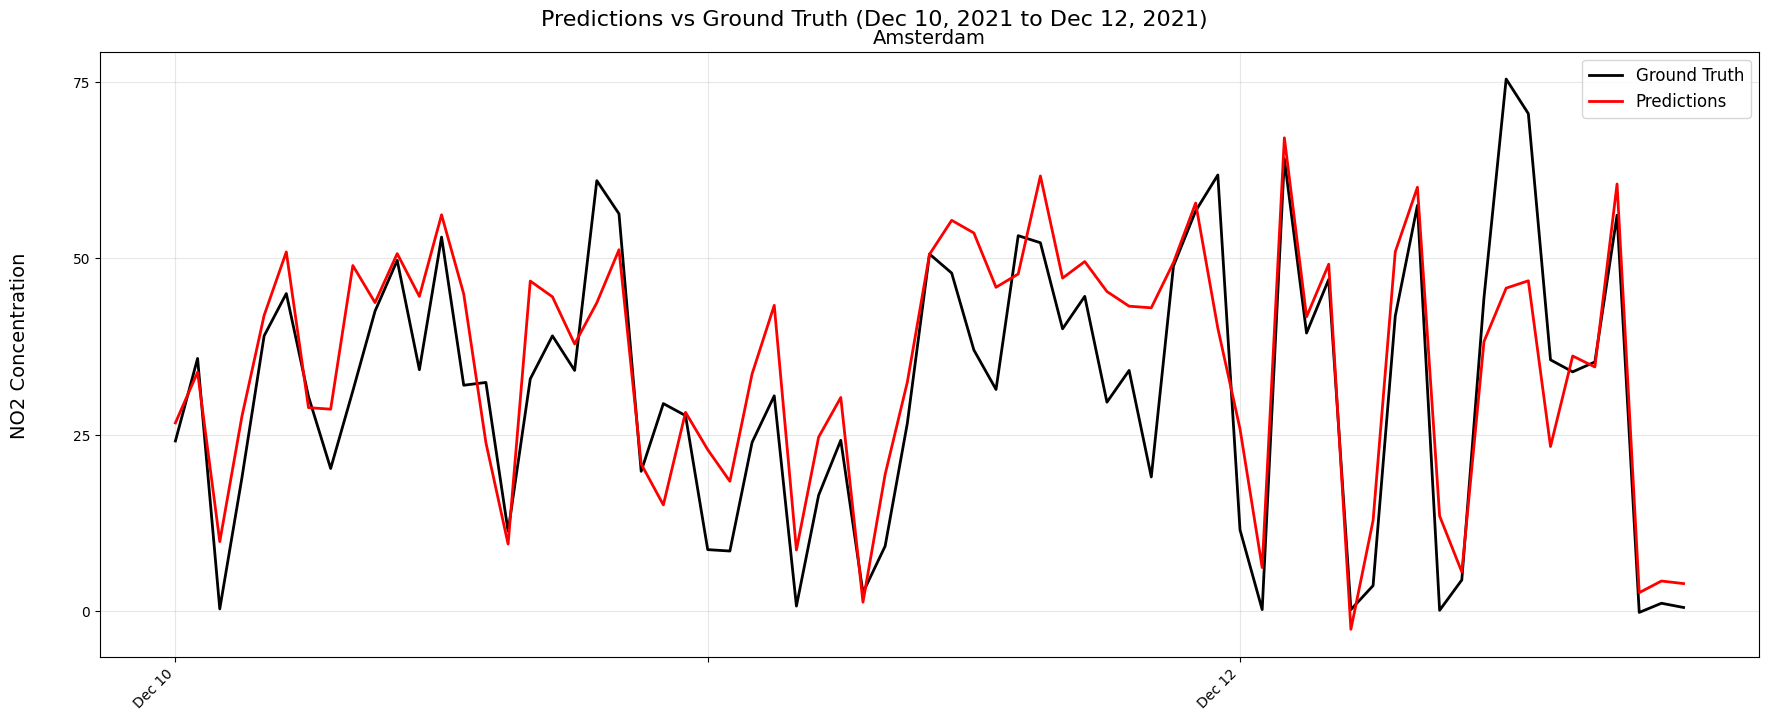

In [28]:
# Process GRU data specifically for NO2
gru_no2_data = process_gru_amsterdam_data("results/gnn_results/GRU_Rotterdam_inference_results_per_eval.json")

# Plot GRU NO2 predictions vs targets
fig = plot_predictions_vs_ground_truth(
    gru_no2_data["predictions"],
    gru_no2_data["targets"],
    city_names=gru_no2_data["city_names"],
    plot_start_date="2021-12-10",
    plot_end_date="2021-12-17",
    n_hours_in=N_HOURS_IN,
    n_hours_out=N_HOURS_OUT,
    figsize=(18, 7),
    test_start_date="2021-12-09"
    
)



## Utrecht

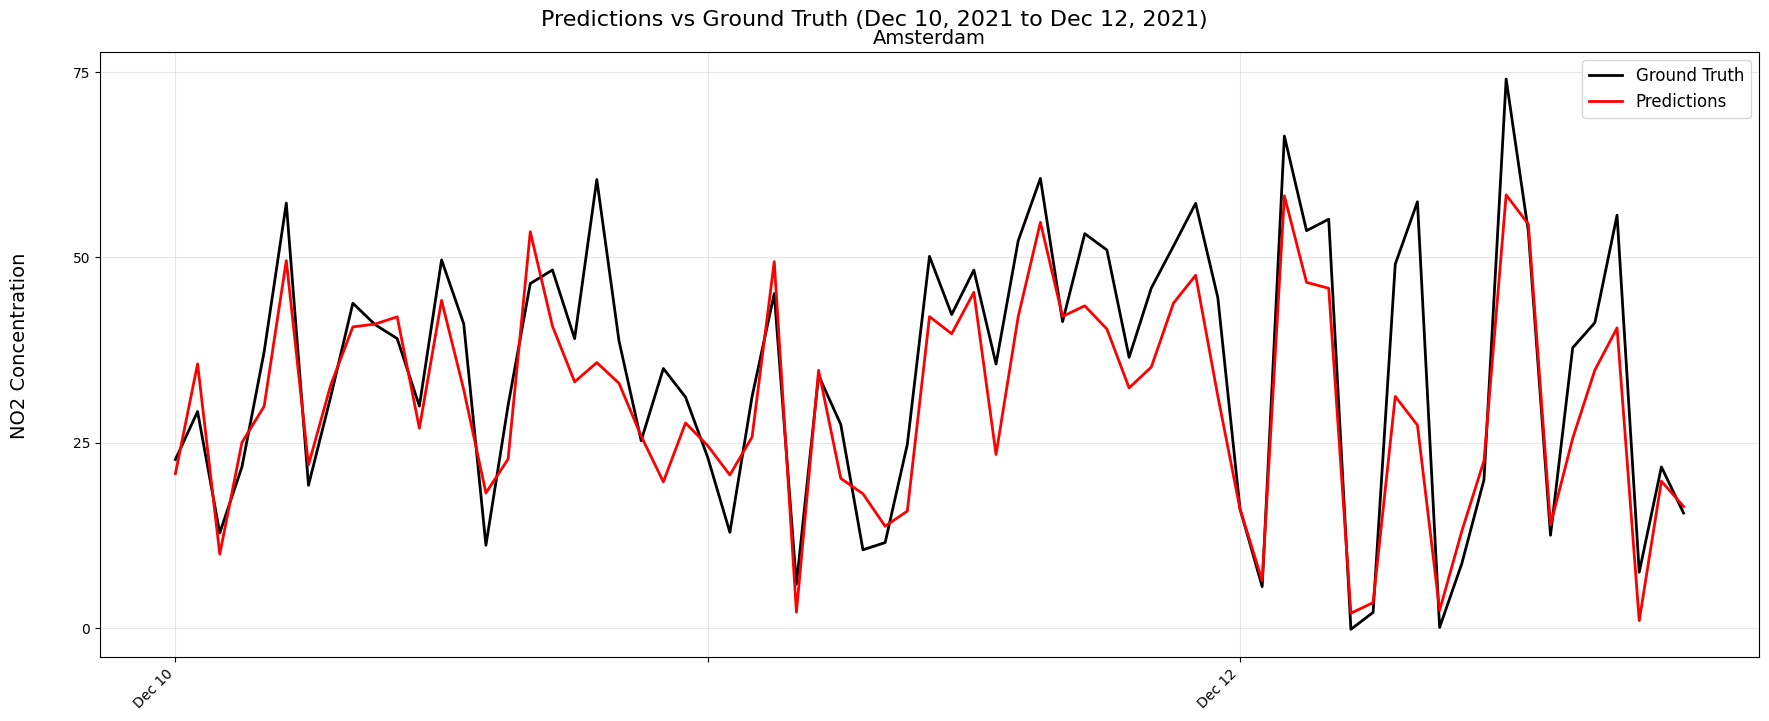

In [29]:
# Process GRU data specifically for NO2
gru_no2_data = process_gru_amsterdam_data("results/gnn_results/GRU_Utrecht_inference_results_per_eval.json")

# Plot GRU NO2 predictions vs targets
fig = plot_predictions_vs_ground_truth(
    gru_no2_data["predictions"],
    gru_no2_data["targets"],
    city_names=gru_no2_data["city_names"],
    plot_start_date="2021-12-10",
    plot_end_date="2021-12-17",
    n_hours_in=N_HOURS_IN,
    n_hours_out=N_HOURS_OUT,
    figsize=(18, 7),
    test_start_date="2021-12-09"
    
)

